In [1]:
import cv2
import numpy as np
import os 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from skimage.morphology import remove_small_objects, remove_small_holes

In [2]:
dataset_path = "/Users/qiubingchen/Downloads/EWS-Dataset"
train_path = os.path.join(dataset_path, "train")

all_train_files = sorted(os.listdir(train_path))
print("Number of files in train", len(all_train_files))
print(all_train_files[:10])

Number of files in train 284
['FPWW0220011_RGB1_20180316_100219_6.png', 'FPWW0220011_RGB1_20180316_100219_6_mask.png', 'FPWW0220032_RGB1_20171213_141430_6.png', 'FPWW0220032_RGB1_20171213_141430_6_mask.png', 'FPWW0220032_RGB1_20180112_121036_6.png', 'FPWW0220032_RGB1_20180112_121036_6_mask.png', 'FPWW0220032_RGB1_20180124_115802_6.png', 'FPWW0220032_RGB1_20180124_115802_6_mask.png', 'FPWW0220032_RGB1_20180207_120354_6.png', 'FPWW0220032_RGB1_20180207_120354_6_mask.png']


In [3]:
train_img_files = sorted([
    f for f in os.listdir(train_path)
    if f.endswith(".png") and "_mask" not in f
])

train_mask_files = sorted([
    f for f in os.listdir(train_path)
    if f.endswith(".png") and "_mask" in f
])

print("Number of train images:", len(train_img_files))
print("Number of train masks:", len(train_mask_files))

    

Number of train images: 142
Number of train masks: 142


Unique values in mask: [  0  70 104 121 138 149 158 169 175 183 189 194 199 203 208 211 214 217
 220 223 225 227 229 231 233 234 237 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255]


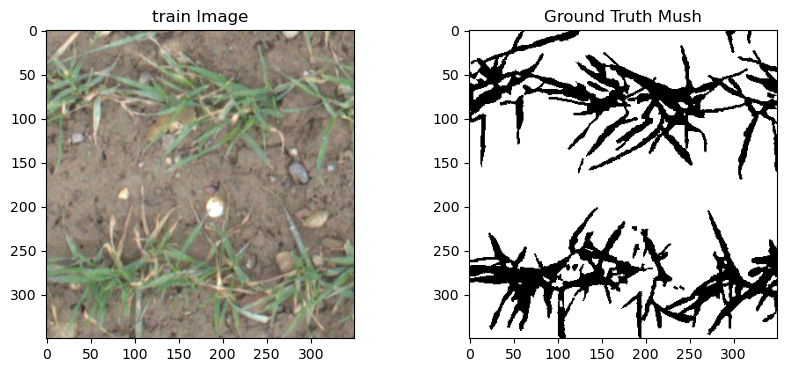

In [4]:
img_path = os.path.join(train_path, train_img_files[0])
mask_path = os.path.join(train_path, train_mask_files[0])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize = (10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("train Image")

plt.subplot(1,2,2)
plt.imshow(mask,cmap='gray')
plt.title("Ground Truth Mush")

print("Unique values in mask:", np.unique(mask))

In [5]:
def get_image_mask_pairs(folder_path):
    all_files = sorted(os.listdir(folder_path))
    img_files = [
        f for f in all_files
        if f.endswith(".png") and "_mask" not in f
    ]

    pairs = []
    for img_name in img_files:
        mask_name = img_name.replace(".png","_mask.png")
        mask_path = os.path.join(folder_path, img_name)
        img_path = os.path.join(folder_path, img_name)
        
        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path))
        else:
            print("Mask not found for:", img_name)

    return pairs

validation_path = os.path.join(dataset_path, "validation")
test_path = os.path.join(dataset_path,  "test")

train_pairs = get_image_mask_pairs(train_path)
validation_pairs = get_image_mask_pairs(validation_path)
test_pairs = get_image_mask_pairs(test_path)

print("Number of train pairs:", len(train_pairs))
print("Number of vaildation pairs:", len(validation_pairs))
print("Number of test pairs:", len(test_pairs))
    

Number of train pairs: 142
Number of vaildation pairs: 24
Number of test pairs: 24


In [6]:
mask_binary = (mask > 0).astype(np.uint8)
print(np.unique(mask))
print(np.unique(mask_binary))

[  0  70 104 121 138 149 158 169 175 183 189 194 199 203 208 211 214 217
 220 223 225 227 229 231 233 234 237 239 240 241 242 243 244 245 246 247
 248 249 250 251 252 253 254 255]
[0 1]


In [7]:
def compute_exg(img_rgb):
    img = img_rgb.astype(np.float32)
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    exg = 2 * G - R - B
    return exg
exg = compute_exg(img)
print("exg shape:", exg.shape)
print("exg min:", exg.min())
print("exg max:", exg.max())


exg shape: (350, 350)
exg min: -52.0
exg max: 139.0


In [8]:
img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
L = img_lab[:,:,0]
a = img_lab[:,:,1]
b = img_lab[:,:,2]
print(L.shape)
print(a.shape)
print(b.shape)

(350, 350)
(350, 350)
(350, 350)


In [9]:
exg = compute_exg(img)
features= np.stack([L,a,b,exg],axis=-1)
print(features.shape)

(350, 350, 4)


In [10]:
X = features.reshape(-1,4)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
labels_2d = labels.reshape(img.shape[0], img.shape[1])
print("labels shape:", labels.shape)
print("labels_2d shape:", labels_2d.shape)
print("unique labels:", np.unique(labels_2d))

labels shape: (122500,)
labels_2d shape: (350, 350)
unique labels: [0 1]


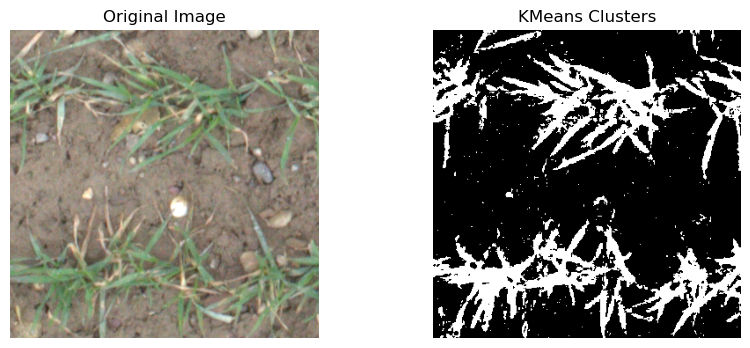

In [11]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(labels_2d,cmap='gray')
plt.title("KMeans Clusters")
plt.axis('off')

plt.show()

In [12]:
for i in range(2):
    mean_exg = exg[labels_2d == i].mean()
    print(f"Cluster{i}, mean ExG = {mean_exg}")

Cluster0, mean ExG = 3.18377423286438
Cluster1, mean ExG = 53.779815673828125


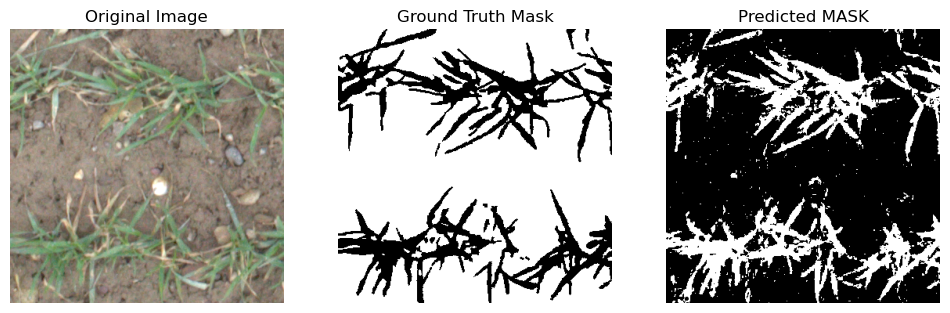

In [13]:
mean_exg_0 = exg[labels_2d ==0].mean()
mean_exg_1 = exg[labels_2d ==1].mean()

if mean_exg_0 > mean_exg_1:
    plant_cluster = 0
else:
    plant_cluster = 1

pred_mask = (labels_2d == plant_cluster).astype(np.uint8)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask_binary, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Predicted MASK")
plt.axis('off')

plt.show()

In [23]:
def kmeans_segment(img, n_clusters=2, min_object_size=100, hole_size=100):
   
    exg = compute_exg(img)

    img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)
    L = img_lab[:, :, 0]
    a = img_lab[:, :, 1]
    b = img_lab[:, :, 2]

    features = np.stack([L, a, b, exg], axis=-1)
    X = features.reshape(-1, 4)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    labels_2d = labels.reshape(img.shape[0], img.shape[1])

    cluster_exg_means = []
    for i in range(n_clusters):
        cluster_pixels = (labels_2d == i)
        if np.sum(cluster_pixels) == 0:
            cluster_exg_means.append(-np.inf)
        else:
            cluster_exg_means.append(exg[cluster_pixels].mean())

    plant_cluster = np.argmax(cluster_exg_means)

    pred_mask = (labels_2d == plant_cluster)

    pred_mask = remove_small_objects(pred_mask, min_size=min_object_size)
    pred_mask = remove_small_holes(pred_mask, area_threshold=hole_size)

    pred_mask = pred_mask.astype(np.uint8) * 255
    kernel = np.ones((3, 3), np.uint8)
    pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_OPEN, kernel)
    pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_CLOSE, kernel)

    pred_mask = (pred_mask > 0).astype(np.uint8)

    return pred_mask

In [24]:
pred_mask_new = kmeans_segment(img, n_clusters=2)

print(pred_mask_new.shape)
print(np.unique(pred_mask_new))

(350, 350)
[0 1]


In [25]:
def evaluate_segmentation(pred_mask, gt_mask):
    pred = (pred_mask > 0).astype(np.uint8)
    gt = (gt_mask > 0).astype(np.uint8)

    tp = np.sum((pred == 1) & (gt == 1))
    fp = np.sum((pred == 1) & (gt == 0))
    fn = np.sum((pred == 0) & (gt == 1))
    tn = np.sum((pred == 0) & (gt == 0))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou
    }

{'precision': np.float64(0.14619995389220541), 'recall': np.float64(0.04064562992714331), 'f1': np.float64(0.06360748572977731), 'iou': np.float64(0.03284844822376373)}


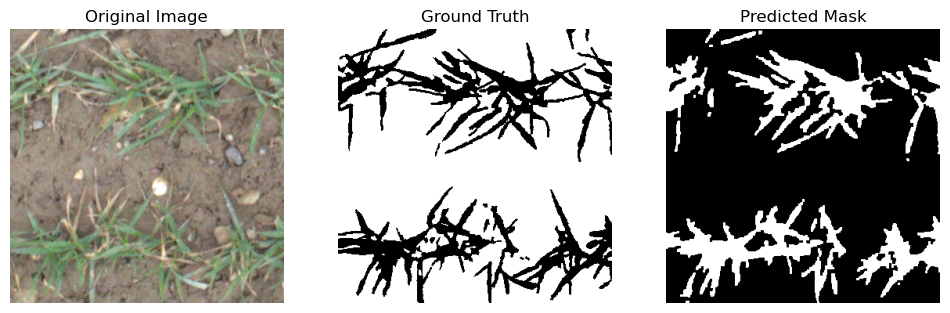

In [26]:
pred_mask = kmeans_segment(img, n_clusters=2)

metrics = evaluate_segmentation(pred_mask, mask_binary)
print(metrics)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_binary, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()


In [27]:
def evaluate_dataset(pairs, n_clusters=2, min_object_size=100, hole_size=100):
    all_metrics = []

    for img_path, mask_path in pairs:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt_mask = (gt_mask > 0).astype(np.uint8)

        pred_mask = kmeans_segment(
            img,
            n_clusters=n_clusters,
            min_object_size=min_object_size,
            hole_size=hole_size
        )

        metrics = evaluate_segmentation(pred_mask, gt_mask)
        all_metrics.append(metrics)

    avg_metrics = {
        "precision": np.mean([m["precision"] for m in all_metrics]),
        "recall": np.mean([m["recall"] for m in all_metrics]),
        "f1": np.mean([m["f1"] for m in all_metrics]),
        "iou": np.mean([m["iou"] for m in all_metrics]),
    }

    return avg_metrics, all_metrics

In [28]:
val_avg_metrics, val_all_metrics = evaluate_dataset(
    validation_pairs,
    n_clusters=2,
    min_object_size=100,
    hole_size=100
)

print("Validation Results:")
for k, v in val_avg_metrics.items():
    print(f"{k}: {v:.4f}")

Validation Results:
precision: 1.0000
recall: 0.3440
f1: 0.4841
iou: 0.3440


In [29]:
settings = [
    {"n_clusters": 2, "min_object_size": 50, "hole_size": 50},
    {"n_clusters": 2, "min_object_size": 100, "hole_size": 100},
    {"n_clusters": 2, "min_object_size": 200, "hole_size": 200},
    {"n_clusters": 3, "min_object_size": 100, "hole_size": 100},
]

for s in settings:
    val_avg_metrics, _ = evaluate_dataset(
        validation_pairs,
        n_clusters=s["n_clusters"],
        min_object_size=s["min_object_size"],
        hole_size=s["hole_size"]
    )

    print("\nSettings:", s)
    for k, v in val_avg_metrics.items():
        print(f"{k}: {v:.4f}")



Settings: {'n_clusters': 2, 'min_object_size': 50, 'hole_size': 50}
precision: 1.0000
recall: 0.3461
f1: 0.4888
iou: 0.3461

Settings: {'n_clusters': 2, 'min_object_size': 100, 'hole_size': 100}
precision: 1.0000
recall: 0.3440
f1: 0.4841
iou: 0.3440

Settings: {'n_clusters': 2, 'min_object_size': 200, 'hole_size': 200}
precision: 1.0000
recall: 0.3425
f1: 0.4792
iou: 0.3425

Settings: {'n_clusters': 3, 'min_object_size': 100, 'hole_size': 100}
precision: 1.0000
recall: 0.1675
f1: 0.2677
iou: 0.1675


In [33]:
test_avg_metrics, test_all_metrics = evaluate_dataset(
    test_pairs,
    n_clusters=2,
    min_object_size=100,
    hole_size=100
)

print("Test Results:")
for k, v in test_avg_metrics.items():
    print(f"{k}: {v:.4f}")

Test Results:
precision: 1.0000
recall: 0.3656
f1: 0.5177
iou: 0.3656
